Weather delays:
weather_conditions
Clear    0.0
Fog      2.0
Rain     1.5
Name: delay_hours, dtype: float64

Driver delays:
name
Pavel Egorov       2.0
Sergey Sidorov     1.5
Aleksey Smirnov    0.0
Ivan Petrov        0.0
Name: delay_hours, dtype: float64

Driver KPI:
                 deliveries  total_volume  total_cost  avg_delay  \
name                                                               
Ivan Petrov               1          32.5     2100.50        0.0   
Aleksey Smirnov           1          22.0     1650.25        0.0   
Sergey Sidorov            1          28.0     1850.00        1.5   
Pavel Egorov              1          35.0     2400.80        2.0   

                 avg_cost_per_km  efficiency  
name                                          
Ivan Petrov                11.67  325.000000  
Aleksey Smirnov            13.75  220.000000  
Sergey Sidorov             12.33   17.500000  
Pavel Egorov               11.43   16.666667  


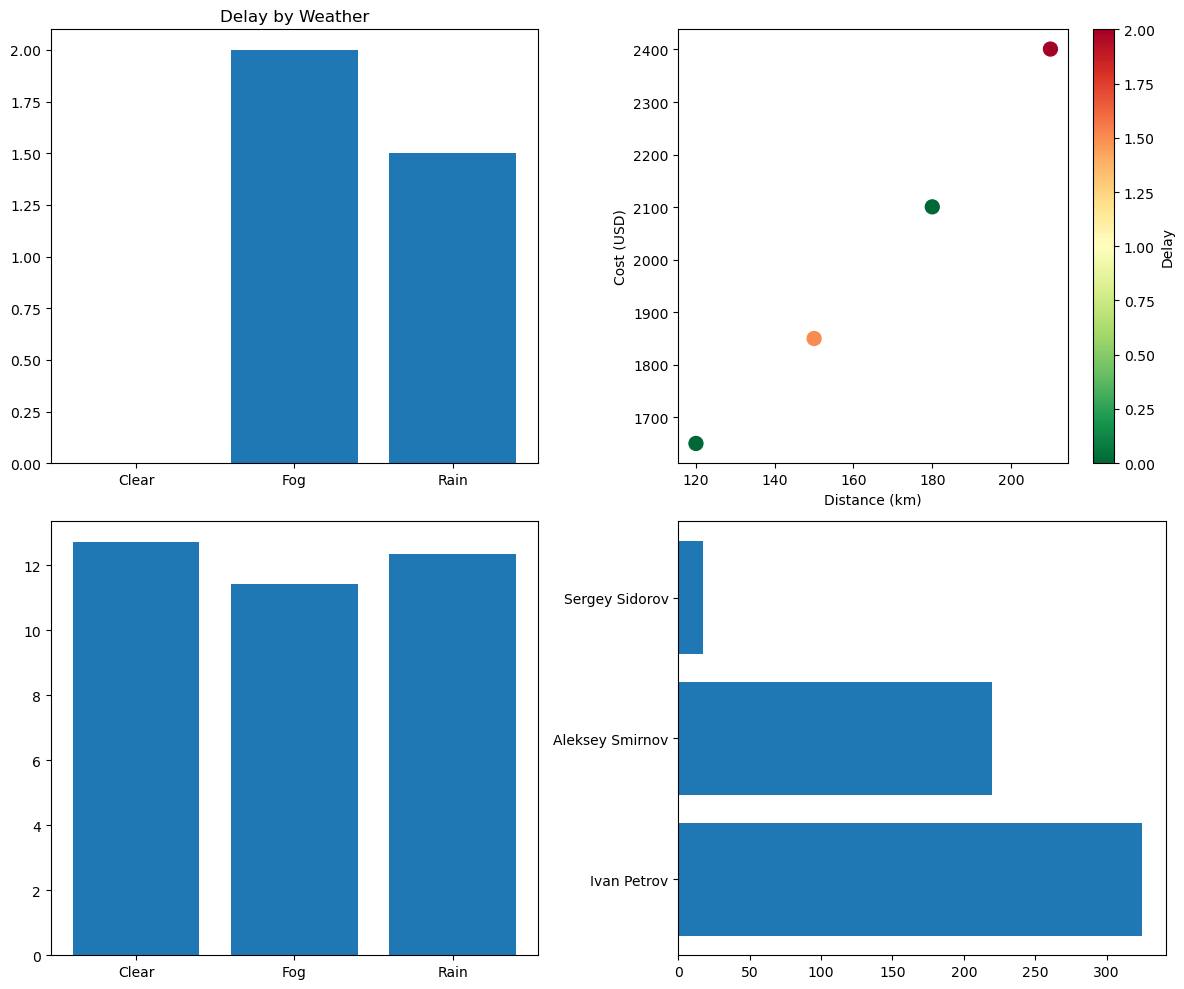

In [1]:
# 06_logistics.ipynb
import pandas as pd
import matplotlib.pyplot as plt
import boto3
from botocore.client import Config
import io

s3 = boto3.client('s3', endpoint_url='http://minio:9000', aws_access_key_id='minioadmin', aws_secret_access_key='minioadmin123', config=Config(signature_version='s3v4'))

def read(key):
    resp = s3.get_object(Bucket='oil-data-lake', Key=key)
    return pd.read_parquet(io.BytesIO(resp['Body'].read()))

def save(df, key):
    buf = io.BytesIO()
    df.to_parquet(buf, index=False)
    buf.seek(0)
    s3.put_object(Bucket='oil-data-lake', Key=key, Body=buf.getvalue())

deliveries = read('raw/deliveries.parquet')
drivers = read('raw/drivers.parquet')
vehicles = read('raw/vehicles.parquet')

df = deliveries.merge(drivers, on='driver_id').merge(vehicles, on='vehicle_id')
df['cost_per_km'] = df['cost_usd'] / df['distance_km']

weather_delays = df.groupby('weather_conditions')['delay_hours'].mean()
driver_delays = df.groupby('name')['delay_hours'].mean().sort_values(ascending=False)

print('Weather delays:')
print(weather_delays)
print('\nDriver delays:')
print(driver_delays)

driver_kpi = df.groupby('name').agg({
    'delivery_id': 'count',
    'volume_ton': 'sum',
    'cost_usd': 'sum',
    'delay_hours': 'mean',
    'cost_per_km': 'mean'
}).round(2)
driver_kpi.columns = ['deliveries', 'total_volume', 'total_cost', 'avg_delay', 'avg_cost_per_km']
driver_kpi['efficiency'] = driver_kpi['total_volume'] / (driver_kpi['avg_delay'] + 0.1)

print('\nDriver KPI:')
print(driver_kpi.sort_values('efficiency', ascending=False))

save(driver_kpi, 'marts/driver_kpi.parquet')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].bar(weather_delays.index, weather_delays.values)
axes[0, 0].set_title('Delay by Weather')

scatter = axes[0, 1].scatter(df['distance_km'], df['cost_usd'], c=df['delay_hours'], cmap='RdYlGn_r', s=100)
axes[0, 1].set_xlabel('Distance (km)')
axes[0, 1].set_ylabel('Cost (USD)')
plt.colorbar(scatter, ax=axes[0, 1], label='Delay')

cost_by_weather = df.groupby('weather_conditions')['cost_per_km'].mean()
axes[1, 0].bar(cost_by_weather.index, cost_by_weather.values)

top_drivers = driver_kpi.nlargest(3, 'efficiency')
axes[1, 1].barh(top_drivers.index, top_drivers['efficiency'])

plt.tight_layout()
plt.savefig('logistics_charts.png')
plt.show()